# K-Means Clustering

## What is K-Means?
- K-Means is an **unsupervised machine learning algorithm**.
- It groups similar data points into **K clusters**.
- Data points within the same cluster are more similar to each other than to those in other clusters.

---

## How K-Means Works

1. Choose the number of clusters (**K**).
2. Randomly initialize **K centroids**.
3. Assign each data point to the nearest centroid.
4. Recalculate the centroid (mean of all points in the cluster).
5. Repeat Steps 3 and 4 until the centroids no longer change or the maximum number of iterations is reached.

---

## Important Terms

- **K** → Number of clusters.
- **Centroid** → Center (mean) of a cluster.
- **Inertia (WCSS)** → Sum of squared distances of data points from their assigned centroid.
- **Cluster** → Group of similar data points.

---

## Choosing the Best K

### Elbow Method
- Train K-Means for different values of **K**.
- Plot **K vs WCSS (Inertia)**.
- Choose the value of **K** where the graph forms an **elbow**.

---

## Why Feature Scaling?

K-Means uses **Euclidean distance**.

If features have different scales, larger-valued features dominate the distance calculation.

**Always scale the data** using `StandardScaler` or `MinMaxScaler`.

---

## Advantages

- Simple and easy to implement.
- Fast on small to medium datasets.
- Works well for well-separated clusters.
- Easy to interpret.

---

## Disadvantages

- Need to specify **K** beforehand.
- Sensitive to outliers.
- Assumes clusters are roughly spherical.
- May converge to a local optimum.

---

## Common Applications

- Customer Segmentation
- Market Basket Analysis
- Image Compression
- Document Clustering
- Recommendation Systems
- Anomaly Detection

---

## Important Hyperparameters

- `n_clusters` → Number of clusters.
- `init` → Method to initialize centroids (`k-means++` recommended).
- `n_init` → Number of times K-Means runs with different initial centroids.
- `max_iter` → Maximum iterations.
- `random_state` → Ensures reproducible results.

---

## Typical Workflow

```
Load Data
     ↓
Select Features
     ↓
Scale Features
     ↓
Find Best K (Elbow Method)
     ↓
Train K-Means
     ↓
Assign Cluster Labels
     ↓
Visualize & Analyze Clusters
```

---

## Common Evaluation Methods

- Elbow Method (WCSS)
- Silhouette Score
- Davies-Bouldin Score
- Calinski-Harabasz Score

---

## Key Points to Remember

- K-Means is an **unsupervised learning** algorithm.
- Uses **Euclidean distance** to assign points to clusters.
- Centroid = Mean of all points in a cluster.
- Scale features before applying K-Means.
- Use the **Elbow Method** or **Silhouette Score** to choose the optimal number of clusters.

In [2]:
import pandas as pd
from jupyter_client.multikernelmanager import kernel_method

In [9]:
df = pd.read_csv("Mall_Customers.csv")

In [10]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
 4   Cluster                 200 non-null    int32
dtypes: int32(1), int64(4)
memory usage: 7.2 KB


In [35]:
df.isna().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64

### Drop Irrelevant columns and Map Gender Column

In [11]:
df = df.drop("CustomerID", axis=1)

In [12]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

In [13]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


### Scaled Dataframe

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [17]:
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)

In [18]:
df_scaled.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


### Find best value for K clusters

In [23]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 15):
    kmeans = KMeans(
        n_clusters = k,
        init = "k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

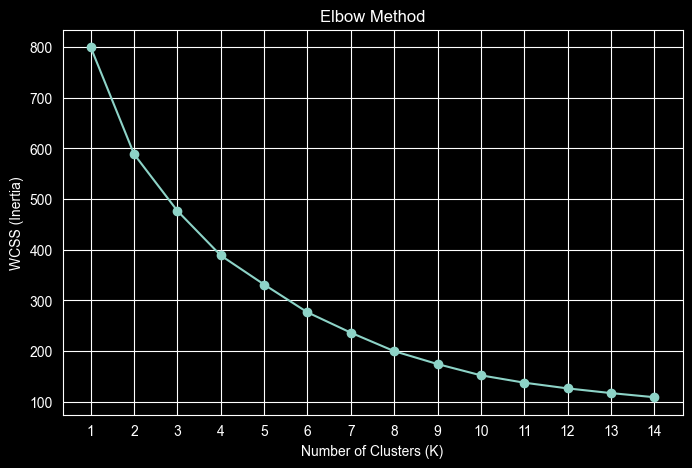

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1, 15), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1,15))
plt.grid(True)

plt.show()

### Train model for finding clusters (similar groups)

In [25]:
kmeans = KMeans(
    n_clusters = 7,
    init = "k-means++",
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [27]:
df["Cluster"] = clusters

In [28]:
df.head() # Resultant Clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,1
1,0,21,15,81,1
2,1,20,16,6,2
3,1,23,16,77,2
4,1,31,17,40,2


### View Cluster Centers

- These are in the scaled feature space.

In [29]:
print(kmeans.cluster_centers_)

[[ 0.88640526  0.86299444 -0.43455895 -0.40762639]
 [-1.12815215 -0.97602698 -0.73705168  0.41603773]
 [ 0.88640526 -0.92608124 -0.70017176  0.28182355]
 [-1.12815215 -0.39989994  1.01344075  1.26040667]
 [-1.12815215  1.28299268 -0.2631146  -0.55597181]
 [ 0.88640526 -0.45245636  0.94327069  1.17982252]
 [-0.12087344 -0.07756323  1.17949408 -1.32321797]]


In [32]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers = pd.DataFrame(centers, columns=df_scaled.columns)

print(centers)

   Gender        Age  Annual Income (k$)  Spending Score (1-100)
0     1.0  50.875000           49.175000               39.700000
1     0.0  25.250000           41.250000               60.916667
2     1.0  25.945946           42.216216               57.459459
3     0.0  33.277778           87.111111               82.666667
4     0.0  56.727273           53.666667               35.878788
5     1.0  32.545455           85.272727               80.590909
6     0.5  37.769231           91.461538               16.115385


### Visualize Clusters (2 Features)
- With only Annual Income and Spending Score, we can visualize the clusters directly.

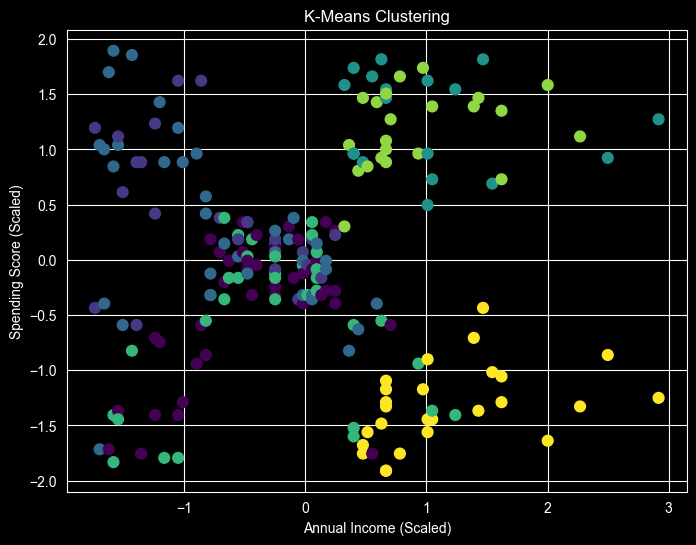

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=clusters,
    cmap="viridis",
    s=60
)

plt.title("K-Means Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()